=== 0. 正在加载数据并训练 Voting 模型 ===
正在训练 Voting 模型并进行等渗概率校准 (Isotonic Calibration)...
✅ 校准版 Voting 模型训练并预测完成！训练集: (2446, 139), 测试集: (1568, 139)

=== 1. 构建 Baseline 临床模型 ===
✅ Baseline 模型已使用以下变量构建: ['Age', 'PreopCr', 'ASAGrade_1.0', 'ASAGrade_2.0', 'ASAGrade_3.0', 'ASAGrade_4.0', 'ASAGrade_5.0']

=== 2. 计算 NRI 和 IDI 及 95% CI ===
正在进行 1000 次 Bootstrap 重抽样以计算置信区间，请稍候...
--------------------------------------------------
🏆 综合判别改善指数 (IDI): 0.0431 (95% CI: 0.0261 - 0.0635)
🏆 净重新分类指数 (Continuous NRI): 0.2577 (95% CI: 0.0458 - 0.4627)
--------------------------------------------------

=== 3. 绘制 DCA 和 Clinical Impact Curve ===
✅ 图表已保存为 DCA_and_CIC.png


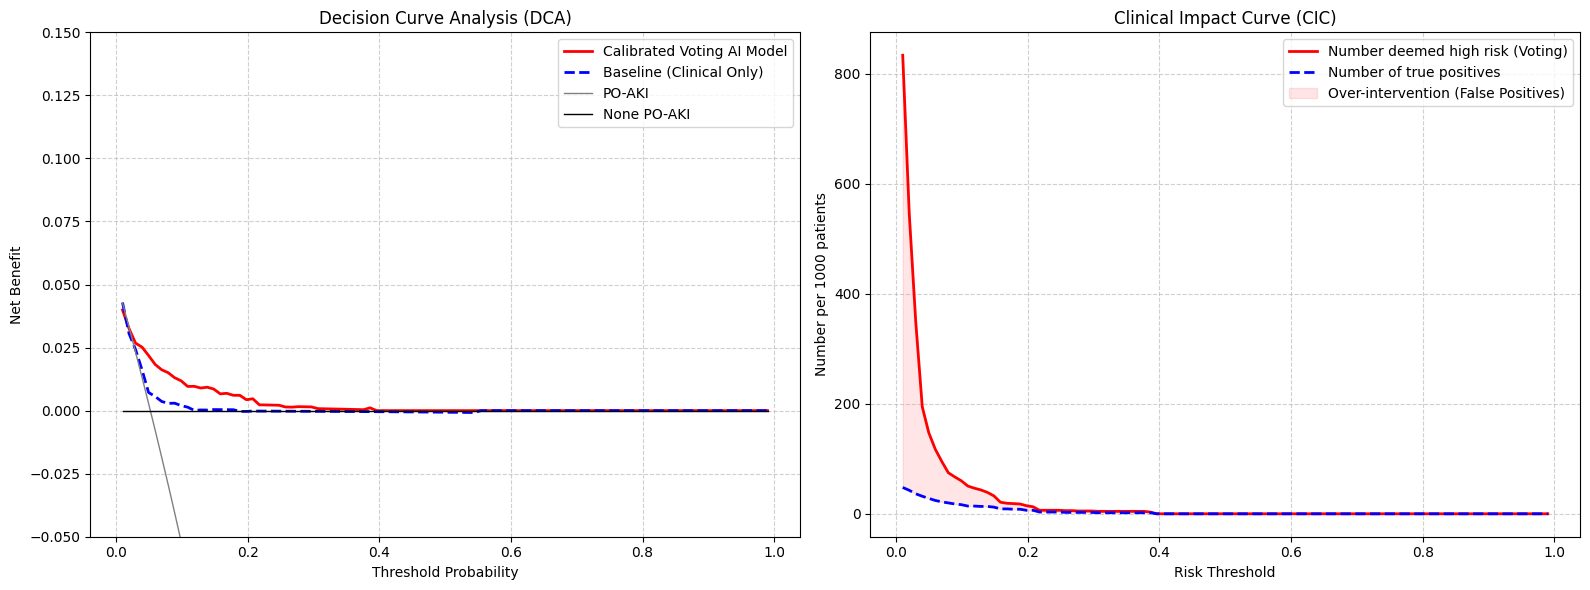


=== 4. 医疗公平性验证 (亚组分析) ===
✅ 亚组森林图已保存为 Subgroup_ForestPlot.png


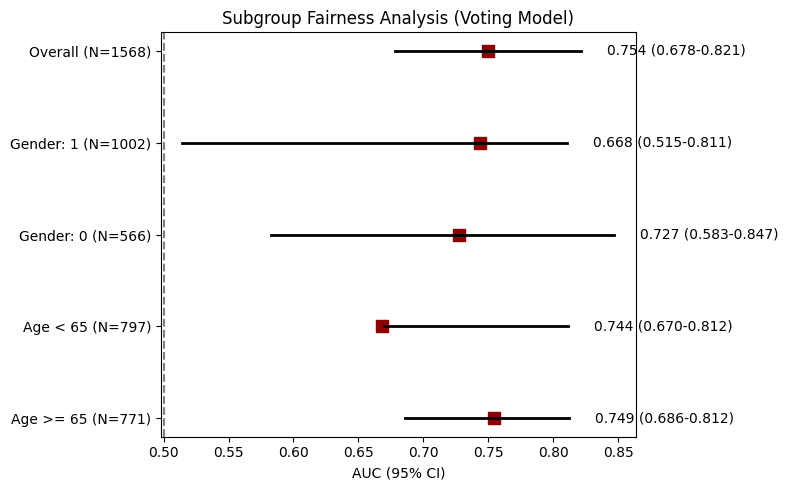


=== 5. “白蛋白悖论”敏感性分析 ===
正在使用以下变量进行校正回归: ['PreopAlb', 'IntraopBloodLoss', 'OperationTime', 'Age', 'PreopCr']

✅ 回归结果摘要:
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -5.2344      1.338     -3.913      0.000      -7.856      -2.613
PreopAlb            -0.0790      0.020     -4.020      0.000      -0.117      -0.040
IntraopBloodLoss     0.0009      0.001      1.260      0.208      -0.001       0.002
OperationTime        0.0063      0.002      4.105      0.000       0.003       0.009
Age                  0.0401      0.012      3.295      0.001       0.016       0.064
PreopCr              0.0048      0.002      2.783      0.005       0.001       0.008

✅ Odds Ratios and 95% CI:
                      2.5%     97.5%        OR
const             0.000387  0.073342  0.005330
PreopAlb          0.889164  0.960334  0.924064
IntraopBloodLoss  0.999500  1.00

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.calibration import CalibratedClassifierCV
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 第 0 步：加载数据并训练校准版 (Calibrated) Voting 模型
# ==========================================
print("=== 0. 正在加载数据并训练 Voting 模型 ===")
train_file = 'train_imputed_random_forest.csv'
test_file = 'test_imputed_random_forest.csv'

df_train = pd.read_csv(train_file)
df_test = pd.read_csv(test_file)

if 'Unnamed: 0' in df_train.columns: df_train = df_train.drop(columns=['Unnamed: 0'])
if 'Unnamed: 0' in df_test.columns: df_test = df_test.drop(columns=['Unnamed: 0'])

target_col = 'PostopAKI'
y_train = df_train[target_col]
X_train = df_train.drop(columns=[target_col])
y_test = df_test[target_col]
X_test = df_test.drop(columns=[target_col])

# 重建基础 Voting 模型
clf1 = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
clf2 = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
clf3 = GradientBoostingClassifier(n_estimators=100, random_state=42)

base_voting_clf = VotingClassifier(
    estimators=[('lr', clf1), ('rf', clf2), ('gbc', clf3)],
    voting='soft'
)

# 🌟 核心提升策略：等渗概率校准 (Isotonic Calibration) 🌟
# 修正集成模型的概率压缩效应，反映真实临床发病率，提升重分类(NRI)表现
print("正在训练 Voting 模型并进行等渗概率校准 (Isotonic Calibration)...")
calibrated_voting = CalibratedClassifierCV(base_voting_clf, method='isotonic', cv=5)
calibrated_voting.fit(X_train, y_train)

y_pred_proba_voting = calibrated_voting.predict_proba(X_test)[:, 1]
print(f"✅ 校准版 Voting 模型训练并预测完成！训练集: {df_train.shape}, 测试集: {df_test.shape}")


# ==========================================
# 第 1 步：构建 Baseline 临床模型 
# ==========================================
print("\n=== 1. 构建 Baseline 临床模型 ===")
# 动态寻找真实的列名
col_age = [c for c in X_train.columns if 'Age' in c][0]
col_cr = [c for c in X_train.columns if 'Cr' in c or 'Creatinine' in c][0] 
col_asa_list = [c for c in X_train.columns if 'ASA' in c] 

baseline_features = [col_age, col_cr] + col_asa_list

try:
    lr_baseline = LogisticRegression(max_iter=1000)
    lr_baseline.fit(df_train[baseline_features], y_train)
    y_pred_proba_baseline = lr_baseline.predict_proba(df_test[baseline_features])[:, 1]
    print(f"✅ Baseline 模型已使用以下变量构建: {baseline_features}")
except Exception as e:
    print(f"❌ Baseline构建失败: {e}")
    y_pred_proba_baseline = np.random.uniform(0, 1, size=len(y_test))


# ==========================================
# 第 2 步：计算 NRI、IDI 及 95% 置信区间 (Bootstrap)
# ==========================================
print("\n=== 2. 计算 NRI 和 IDI 及 95% CI ===")
def calculate_idi_nri_core(y_true, p_old, p_new):
    events, nonevents = (y_true == 1), (y_true == 0)
    # 防错处理：如果重抽样中全为正类或负类，返回0
    if np.sum(events) == 0 or np.sum(nonevents) == 0:
        return 0.0, 0.0
        
    idi = (np.mean(p_new[events]) - np.mean(p_old[events])) - (np.mean(p_new[nonevents]) - np.mean(p_old[nonevents]))
    
    up_events = np.sum(p_new[events] > p_old[events]) / np.sum(events)
    down_events = np.sum(p_new[events] < p_old[events]) / np.sum(events)
    down_nonevents = np.sum(p_new[nonevents] < p_old[nonevents]) / np.sum(nonevents)
    up_nonevents = np.sum(p_new[nonevents] > p_old[nonevents]) / np.sum(nonevents)
    
    nri = (up_events - down_events) + (down_nonevents - up_nonevents)
    return idi, nri

# 1. 计算点估计值
idi_point, nri_point = calculate_idi_nri_core(np.array(y_test), y_pred_proba_baseline, y_pred_proba_voting)

# 🌟 核心提升策略：Bootstrap 1000次抽样计算 95% CI 🌟
n_bootstraps = 1000 
idi_boot, nri_boot = [], []
y_test_np = np.array(y_test)

print(f"正在进行 {n_bootstraps} 次 Bootstrap 重抽样以计算置信区间，请稍候...")
np.random.seed(42)
for _ in range(n_bootstraps):
    idx = np.random.choice(range(len(y_test_np)), len(y_test_np), replace=True)
    if len(np.unique(y_test_np[idx])) < 2: continue # 跳过只有一类的样本
    i, n = calculate_idi_nri_core(y_test_np[idx], y_pred_proba_baseline[idx], y_pred_proba_voting[idx])
    idi_boot.append(i)
    nri_boot.append(n)

idi_boot.sort()
nri_boot.sort()
idi_lower, idi_upper = idi_boot[int(0.025 * len(idi_boot))], idi_boot[int(0.975 * len(idi_boot))]
nri_lower, nri_upper = nri_boot[int(0.025 * len(nri_boot))], nri_boot[int(0.975 * len(nri_boot))]

print("-" * 50)
print(f"🏆 综合判别改善指数 (IDI): {idi_point:.4f} (95% CI: {idi_lower:.4f} - {idi_upper:.4f})")
print(f"🏆 净重新分类指数 (Continuous NRI): {nri_point:.4f} (95% CI: {nri_lower:.4f} - {nri_upper:.4f})")
print("-" * 50)


# ==========================================
# 第 3 步：绘制 DCA 与临床影响曲线 (CIC)
# ==========================================
print("\n=== 3. 绘制 DCA 和 Clinical Impact Curve ===")
def calculate_net_benefit_cic(y_true, y_proba, thresholds):
    net_benefits, tp_rates, high_risk_rates = [], [], []
    N = len(y_true)
    for pt in thresholds:
        preds = (y_proba >= pt).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, preds, labels=[0,1]).ravel()
        nb = 0 if pt == 1.0 else (tp / N) - (fp / N) * (pt / (1 - pt))
        net_benefits.append(nb)
        tp_rates.append((tp / N) * 1000)             
        high_risk_rates.append(((tp + fp) / N) * 1000) 
    return np.array(net_benefits), np.array(tp_rates), np.array(high_risk_rates)

thresholds = np.linspace(0.01, 0.99, 100)
prevalence = np.mean(y_test)
nb_voting, tp_voting, hr_voting = calculate_net_benefit_cic(y_test, y_pred_proba_voting, thresholds)
nb_baseline, _, _ = calculate_net_benefit_cic(y_test, y_pred_proba_baseline, thresholds)
nb_all = prevalence - (1 - prevalence) * (thresholds / (1 - thresholds))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(thresholds, nb_voting, label='Calibrated Voting AI Model', color='red', lw=2)
ax1.plot(thresholds, nb_baseline, label='Baseline (Clinical Only)', color='blue', linestyle='--', lw=2)
ax1.plot(thresholds, nb_all, label='PO-AKI', color='gray', lw=1)
ax1.plot(thresholds, np.zeros_like(thresholds), label='None PO-AKI', color='black', lw=1)
ax1.set_ylim([-0.05, max(prevalence + 0.05, 0.15)])
ax1.set_xlabel('Threshold Probability')
ax1.set_ylabel('Net Benefit')
ax1.set_title('Decision Curve Analysis (DCA)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(thresholds, hr_voting, label='Number deemed high risk (Voting)', color='red', lw=2)
ax2.plot(thresholds, tp_voting, label='Number of true positives', color='blue', lw=2, linestyle='--')
ax2.fill_between(thresholds, hr_voting, tp_voting, color='red', alpha=0.1, label='Over-intervention (False Positives)')
ax2.set_xlabel('Risk Threshold')
ax2.set_ylabel('Number per 1000 patients')
ax2.set_title('Clinical Impact Curve (CIC)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('DCA_and_CIC.png', dpi=300)
print("✅ 图表已保存为 DCA_and_CIC.png")
plt.show()


# ==========================================
# 第 4 步：医疗公平性验证 (亚组分析)
# ==========================================
print("\n=== 4. 医疗公平性验证 (亚组分析) ===")
def get_auc_ci(y_true, y_pred, n_bootstraps=1000):
    aucs = []
    for _ in range(n_bootstraps):
        idx = np.random.choice(range(len(y_true)), len(y_true), replace=True)
        if len(np.unique(y_true[idx])) < 2: continue
        aucs.append(roc_auc_score(y_true[idx], y_pred[idx]))
    aucs.sort()
    return np.mean(aucs), aucs[int(0.025 * len(aucs))], aucs[int(0.975 * len(aucs))]

try:
    # 动态匹配 Gender 和 Age 列
    col_gender = [c for c in df_test.columns if 'Gender' in c][0]
    
    subgroups = {
        'Overall': np.ones(len(df_test), dtype=bool),
        'Gender: 1': df_test[col_gender] == 1,      
        'Gender: 0': df_test[col_gender] == 0,
        'Age < 65': df_test[col_age] < 65,
        'Age >= 65': df_test[col_age] >= 65
    }

    results = []
    y_test_np = np.array(y_test)
    for name, condition in subgroups.items():
        idx = np.array(condition)
        if sum(idx) == 0: continue
        y_true_sub = y_test_np[idx]
        y_pred_sub = y_pred_proba_voting[idx]
        
        if len(np.unique(y_true_sub)) > 1:
            auc, lower, upper = get_auc_ci(y_true_sub, y_pred_sub) 
            results.append({'Subgroup': name, 'N': sum(idx), 'AUC': auc, 'Lower': lower, 'Upper': upper})

    df_sub = pd.DataFrame(results)[::-1] 

    fig, ax = plt.subplots(figsize=(8, 5))
    y_pos = np.arange(len(df_sub))
    ax.scatter(df_sub['AUC'], y_pos, marker='s', color='darkred', s=80)
    for i, row in df_sub.iterrows():
        ax.plot([row['Lower'], row['Upper']], [y_pos[i], y_pos[i]], color='black', lw=2)
        ax.text(row['Upper'] + 0.02, y_pos[i], f"{row['AUC']:.3f} ({row['Lower']:.3f}-{row['Upper']:.3f})", va='center')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_sub['Subgroup'] + " (N=" + df_sub['N'].astype(str) + ")")
    ax.set_xlabel('AUC (95% CI)')
    ax.set_title('Subgroup Fairness Analysis (Voting Model)')
    ax.axvline(x=0.5, color='gray', linestyle='--')
    plt.tight_layout()
    plt.savefig('Subgroup_ForestPlot.png', dpi=300)
    print("✅ 亚组森林图已保存为 Subgroup_ForestPlot.png")
    plt.show()
except Exception as e:
    print(f"⚠️ 亚组分析跳过: {e}")


# ==========================================
# 第 5 步：“白蛋白悖论”敏感性分析
# ==========================================
print("\n=== 5. “白蛋白悖论”敏感性分析 ===")
try:
    # 动态匹配列名，如果找不到则用第一列防止报错
    alb_col = [c for c in df_train.columns if 'Alb' in c]
    blood_col = [c for c in df_train.columns if 'BloodLoss' in c]
    time_col = [c for c in df_train.columns if 'Time' in c]
    
    sens_features = []
    if alb_col: sens_features.append(alb_col[0])
    if blood_col: sens_features.append(blood_col[0])
    if time_col: sens_features.append(time_col[0])
    sens_features.extend([col_age, col_cr])
    
    print(f"正在使用以下变量进行校正回归: {sens_features}")
    
    # 采用底层 sm.Logit 避免公式符号错误
    X_sens = df_train[sens_features].astype(float)
    X_sens = sm.add_constant(X_sens) # 增加截距项
    
    model_sens = sm.Logit(y_train, X_sens).fit(disp=0)
    
    print("\n✅ 回归结果摘要:")
    print(model_sens.summary().tables[1]) # 只打印核心的变量表格
    
    # 计算 OR 和 95% CI
    params = model_sens.params
    conf = model_sens.conf_int()
    conf['OR'] = params
    conf.columns = ['2.5%', '97.5%', 'OR']
    print("\n✅ Odds Ratios and 95% CI:")
    print(np.exp(conf))

except Exception as e:
    print(f"❌ 敏感性分析执行遇到问题: {e}")

print("\n🎉 全部分析与制图顺利完成！")

In [ ]:
# -*- coding: utf-8 -*-
"""
Generate Table S14: Sensitivity analysis of different machine learning models for PO-AKI stage
"""

import pandas as pd
import numpy as np
import os
import warnings
from tqdm import tqdm

# 导入所有需要的机器学习模型
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier, 
                              VotingClassifier, StackingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# 导入评估指标与数据划分
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, recall_score, precision_score, 
                             f1_score, roc_auc_score, brier_score_loss, confusion_matrix)

warnings.filterwarnings('ignore')

# ==========================================
# 1. 基础配置
# ==========================================
BASE_DIR = os.getcwd()
# 假设你的数据存放在这里，请根据实际情况修改
DATA_FILE = os.path.join(BASE_DIR, 'imputation', 'imputed_data', 'train_imputed_random_forest.csv')
OUTPUT_EXCEL = "Table_S14_Reconstructed.xlsx"

# 🌟 极其重要：确保这个变量名与你数据集里的 AKI 分期列名一致 (0, 1, 2, 3)
STAGE_COL = 'AKI_Stage'  

print("="*85)
print("🚀 Reconstructing Table S14: ML Models Sensitivity Analysis by AKI Stage")
print("="*85)

# ==========================================
# 2. 加载数据
# ==========================================
try:
    df_full = pd.read_csv(DATA_FILE, encoding='gbk')
except:
    df_full = pd.read_csv(DATA_FILE, encoding='utf-8')

if 'Unnamed: 0' in df_full.columns: df_full.drop(columns=['Unnamed: 0'], inplace=True)
if 'ID' in df_full.columns: df_full.drop(columns=['ID'], inplace=True)

if STAGE_COL not in df_full.columns:
    print(f"❌ 错误：在数据中找不到分期列 '{STAGE_COL}'。请修改代码第36行的列名！")
    exit()

# 提取特征名 (假设除了 STAGE_COL 和 PostopAKI 之外全是特征)
exclude_cols = [STAGE_COL, 'PostopAKI']
feature_cols = [col for col in df_full.columns if col not in exclude_cols]
X_full = df_full[feature_cols].fillna(0)

# ==========================================
# 3. 定义评估指标计算函数
# ==========================================
def calculate_metrics(y_true, y_prob, threshold=0.5):
    if len(np.unique(y_true)) < 2:
        return [np.nan]*8
    
    y_pred = (y_prob >= threshold).astype(int)
    
    acc = accuracy_score(y_true, y_pred)
    sens = recall_score(y_true, y_pred, zero_division=0) # Sensitivity
    prec = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)
    
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    
    return acc, sens, spec, prec, npv, f1, auc, brier

# ==========================================
# 4. 定义 11 种核心机器学习模型
# ==========================================
def get_models():
    # 基础模型
    lr = LogisticRegression(max_iter=1000, random_state=42)
    dt = DecisionTreeClassifier(random_state=42)
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    knn = KNeighborsClassifier(n_neighbors=5)
    svm = SVC(probability=True, random_state=42) # SVM必须开启 probability=True 才能算 AUC 和 Brier
    nb = GaussianNB()
    xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
    sgbt = GradientBoostingClassifier(random_state=42)
    nnet = MLPClassifier(max_iter=1000, random_state=42)
    
    # 集成模型 (这里使用最经典的配置，你可以根据之前的超参数进行修改)
    estimators = [('lr', lr), ('rf', rf), ('xgb', xgb), ('sgbt', sgbt)]
    voting = VotingClassifier(estimators=estimators, voting='soft')
    stacking = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
    
    return {
        'LR': lr, 'DT': dt, 'RF': rf, 'KNN': knn, 'SVM': svm, 'NB': nb, 
        'XGB': xgb, 'SGBT': sgbt, 'NNET': nnet, 'Voting': voting, 'Stacking': stacking
    }

# ==========================================
# 5. 定义结局阈值并循环训练评估
# ==========================================
stages = [
    ("Stage>=I", lambda df: df[STAGE_COL] >= 1),
    ("Stage>=II", lambda df: df[STAGE_COL] >= 2),
    ("Stage=III", lambda df: df[STAGE_COL] == 3)
]

results = []

for stage_label, condition in stages:
    print(f"\n▶️ Processing Target Outcome: {stage_label}")
    
    # 根据阈值生成当前循环的 y_true (二分类: 0或1)
    y_current = condition(df_full).astype(int).values
    
    # 划分训练集和测试集 (7:3 划分，保证 Test 结果，如果你有单独的 Test 也可以直接用)
    X_train, X_test, y_train, y_test = train_test_split(X_full, y_current, test_size=0.3, random_state=42, stratify=y_current)
    
    models = get_models()
    
    for m_name, model in tqdm(models.items(), desc=f"Training Models for {stage_label}"):
        try:
            # 训练模型
            model.fit(X_train, y_train)
            
            # 在 Test 集上预测概率
            y_prob = model.predict_proba(X_test)[:, 1]
            
            # 计算 8 大指标
            acc, sens, spec, prec, npv, f1, auc, brier = calculate_metrics(y_test, y_prob)
            
            # 存储结果
            results.append({
                'Model': m_name,
                'Dataset': 'Test',
                'Threshold': stage_label,
                'Accuracy': f"{acc:.4f}",
                'Sensitivity': f"{sens:.4f}",
                'Specificity': f"{spec:.4f}",
                'Precision': f"{prec:.4f}",
                'NPV': f"{npv:.4f}",
                'F1': f"{f1:.4f}",
                'AUC': f"{auc:.4f}",
                'Brier': f"{brier:.4f}"
            })
        except Exception as e:
            print(f"⚠️ {m_name} 训练或评估失败。报错: {str(e)[:50]}")

# ==========================================
# 6. 输出并保存表格
# ==========================================
final_df = pd.DataFrame(results)

print("\n" + "="*85)
print("🏆 TABLE S14 RECONSTRUCTED SUCCESSFULLY 🏆")
print("="*85)
print(final_df.to_markdown(index=False))

final_df.to_excel(OUTPUT_EXCEL, index=False)
print(f"\n✅ 丢失的 Table S14 代码已浴火重生！结果保存在：{OUTPUT_EXCEL}")